<a href="https://colab.research.google.com/github/MayerT1/Prep_GEDI/blob/main/GEDI_L1B_L2A_L2B_Native_EO_Res_Multi_Branch_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rasterio torch tqdm matplotlib timm torchmetrics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [208]:
import os

# Define the base project folder and subdirectories
base_dir = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project'
subdirs = [
    'data_32_32_patches_11_4_25',
    'target_data',
    'data',
    'data_NaN_filtered',
    'models',
    "model_animations",
    'scripts',
    'notebooks',
    'config',
    'results',
    'prediction_surface'
]

# Create each subdirectory
for subdir in subdirs:
    path = os.path.join(base_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created: {path}")

Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/target_data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_NaN_filtered
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/models
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/model_animations
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/scripts
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/notebooks
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/config
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/results
Created: /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/prediction_surface


# 11/14 dev

# Sort Find Prep data

In [235]:
import os
import re
from collections import Counter

RASTER_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/data_32_32_patches_11_4_25"


In [141]:
pattern = re.compile(
    r"(?P<covariate>.*?)_"
    r"(?P<split>train|test|val)_"
    r"(?P<product_field>GEDI_[A-Z0-9]+)_"
    r"(?P<shot>[0-9]+)_"
    r"(?P<row_id>[0-9]+)_block_"
    r"(?P<block_id>[0-9]+)\.tif$"
)


In [236]:
tif_files = [f for f in os.listdir(RASTER_DIR) if f.endswith(".tif")]

selected_files = []
splits = []

for filename in tif_files:
    m = pattern.match(filename)
    if m:
        if m.group("product_field") == "GEDI_L2A":
            selected_files.append(filename)
            splits.append(m.group("split"))


In [237]:
split_counts = Counter(splits)
split_counts


Counter({'train': 1777, 'val': 211, 'test': 426})

In [238]:
print("Found", len(selected_files), "TIFFs with product_field = GEDI_L2A")

print("\nSplit counts:")
for k, v in split_counts.items():
    print(f"{k}: {v}")

print("\nFirst 10 selected TIFFs:")
for f in selected_files[:10]:
    print(f)


Found 2414 TIFFs with product_field = GEDI_L2A

Split counts:
train: 1777
val: 211
test: 426

First 10 selected TIFFs:
landsatidx_train_GEDI_L2A_2020196021509_983_block_5953898.tif
landsatidx_train_GEDI_L2A_2021135083748_60_block_5963898.tif
landsatidx_train_GEDI_L2A_2020196021509_932_block_5923895.tif
landsatidx_train_GEDI_L2A_2022358084911_1250_block_5963891.tif
landsatidx_train_GEDI_L2A_2022358084911_1357_block_6033898.tif
landsatidx_train_GEDI_L2A_2021135083748_673_block_6033891.tif
landsatidx_train_GEDI_L2A_2022139064237_695_block_5923888.tif
landsatidx_train_GEDI_L2A_2020196021509_1434_block_5953897.tif
landsatidx_train_GEDI_L2A_2021135083748_1509_block_5943897.tif
landsatidx_train_GEDI_L2A_2022358084911_888_block_6023898.tif


# Investigate a set of Tifs before modifying/prepping

In [145]:
import random

sample_files = random.sample(selected_files, 5)
sample_files


['hls_train_GEDI_L2A_2022139064237_695_block_5923888.tif',
 'landsatidx_train_GEDI_L2A_2021135083748_512_block_5953899.tif',
 'landsat_train_GEDI_L2A_2020196021509_484_block_5943899.tif',
 'landsat_train_GEDI_L2A_2020196021509_1434_block_5953897.tif',
 'landsatidx_train_GEDI_L2A_2020196021509_1436_block_5953897.tif']


FILE: hls_train_GEDI_L2A_2022139064237_695_block_5923888.tif
BANDS: 7
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.6036474108695984
      max:  0.8263992667198181
      mean: 0.7498262001274871
      std:  0.038562563725756345

  Band 2 statistics:
      min:  -0.7816430330276489
      max:  -0.5938231348991394
      mean: -0.7255414234229169
      std:  0.02832269944094739

  Band 3 statistics:
      min:  -0.6803157329559326
      max:  -0.5116942524909973
      mean: -0.6064875238681504
      std:  0.022680267469652394

  Band 4 statistics:
      min:  0.2751654088497162
      max:  0.5302377939224243
      mean: 0.4184155824319544
      std:  0.04285380244840876

  Band 5 statistics:
      min:  -0.006707495078444481
      max:  0.34837424755096436
      mean: 0.21359853595709938
      std:  0.053162809449672485

  Band 6 statistics:
      min:  -0.34837424755096436
      max:  0.006707495078444481
  

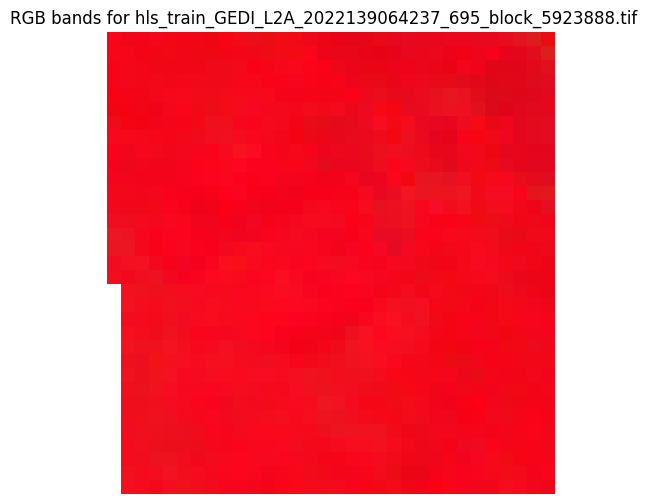


FILE: landsatidx_train_GEDI_L2A_2021135083748_512_block_5953899.tif
BANDS: 7
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.3122198283672333
      max:  0.7989429235458374
      mean: 0.6295279809320816
      std:  0.08811693179233232

  Band 2 statistics:
      min:  -0.7611373662948608
      max:  -0.4317646920681
      mean: -0.6413135291568942
      std:  0.05529150919969571

  Band 3 statistics:
      min:  -0.6992501020431519
      max:  -0.4737332761287689
      mean: -0.6088412547461804
      std:  0.03863841210576507

  Band 4 statistics:
      min:  0.16972799599170685
      max:  0.5381988883018494
      mean: 0.3212072238586056
      std:  0.057128262558997035

  Band 5 statistics:
      min:  -0.17492754757404327
      max:  0.3326405882835388
      mean: 0.05584302265194366
      std:  0.09358430480474868

  Band 6 statistics:
      min:  -0.3326405882835388
      max:  0.17492754757404327
   

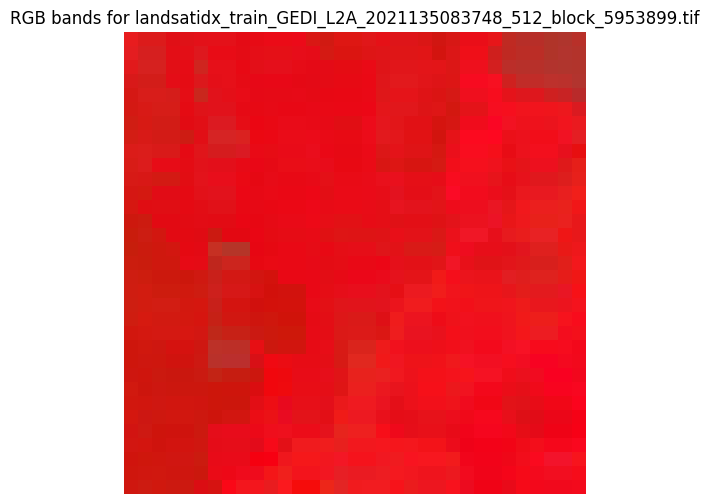


FILE: landsat_train_GEDI_L2A_2020196021509_484_block_5943899.tif
BANDS: 6
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.015434999950230122
      max:  0.10811000317335129
      mean: 0.05438939402695776
      std:  0.016674095978195254

  Band 2 statistics:
      min:  0.0174150001257658
      max:  0.09147249907255173
      mean: 0.04707797982407558
      std:  0.009072525090156991

  Band 3 statistics:
      min:  7875.0
      max:  9797.0
      mean: 8423.59090909091
      std:  210.6017025928001

  Band 4 statistics:
      min:  0.05508999899029732
      max:  0.4067875146865845
      mean: 0.21195176738777
      std:  0.05320719719796778

  Band 5 statistics:
      min:  0.05473250150680542
      max:  0.33468249440193176
      mean: 0.21055133802229598
      std:  0.04794219457942205

  Band 6 statistics:
      min:  8539.0
      max:  15459.0
      mean: 11671.19375573921
      std:  1265.6821067081

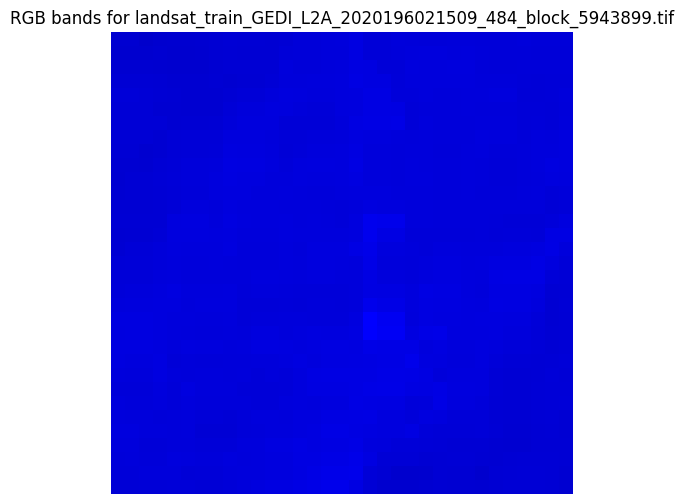


FILE: landsat_train_GEDI_L2A_2020196021509_1434_block_5953897.tif
BANDS: 6
SIZE (pixels): 33 x 33
TOTAL PIXELS: 1089
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.021870000287890434
      max:  0.07568749785423279
      mean: 0.04898717175378944
      std:  0.010350357189555508

  Band 2 statistics:
      min:  0.03119250014424324
      max:  0.0547187514603138
      mean: 0.04262488634694159
      std:  0.002919294338062237

  Band 3 statistics:
      min:  7894.0
      max:  8622.0
      mean: 8299.005509641873
      std:  99.30515929206385

  Band 4 statistics:
      min:  0.12249249964952469
      max:  0.32951250672340393
      mean: 0.2162324369323155
      std:  0.03506943771683439

  Band 5 statistics:
      min:  0.10486499965190887
      max:  0.26370498538017273
      mean: 0.19008006296429314
      std:  0.02420855584819212

  Band 6 statistics:
      min:  9085.0
      max:  12818.0
      mean: 11003.269054178145
      std:  704.15891

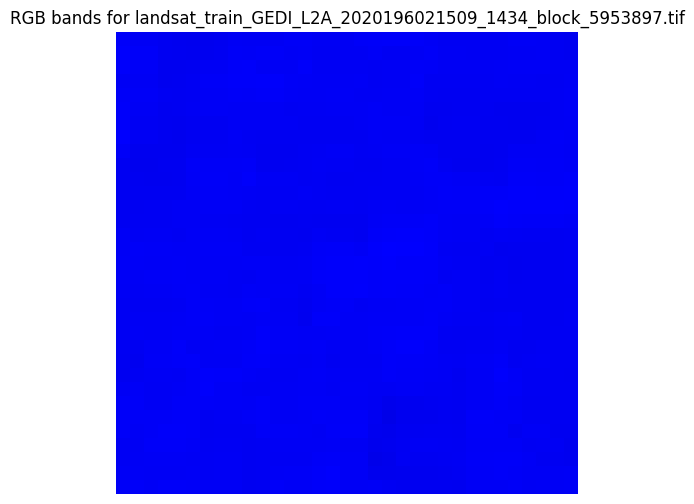


FILE: landsatidx_train_GEDI_L2A_2020196021509_1436_block_5953897.tif
BANDS: 7
SIZE (pixels): 33 x 34
TOTAL PIXELS: 1122
SPATIAL RESOLUTION: 30.0 x 30.0 (approx meters)

  Band 1 statistics:
      min:  0.4940267503261566
      max:  0.8419796824455261
      mean: 0.6331492823394225
      std:  0.0786885925311476

  Band 2 statistics:
      min:  -0.7595598697662354
      max:  -0.5556578636169434
      mean: -0.6672642693693838
      std:  0.0363364518868069

  Band 3 statistics:
      min:  -0.6937260627746582
      max:  -0.47635960578918457
      mean: -0.6286140651360765
      std:  0.029199240758033426

  Band 4 statistics:
      min:  0.21926888823509216
      max:  0.5135061144828796
      mean: 0.3286741027830969
      std:  0.05690098157429358

  Band 5 statistics:
      min:  -0.1054437980055809
      max:  0.44376489520072937
      mean: 0.067523365529434
      std:  0.08260031650330808

  Band 6 statistics:
      min:  -0.44376489520072937
      max:  0.1054437980055809
  

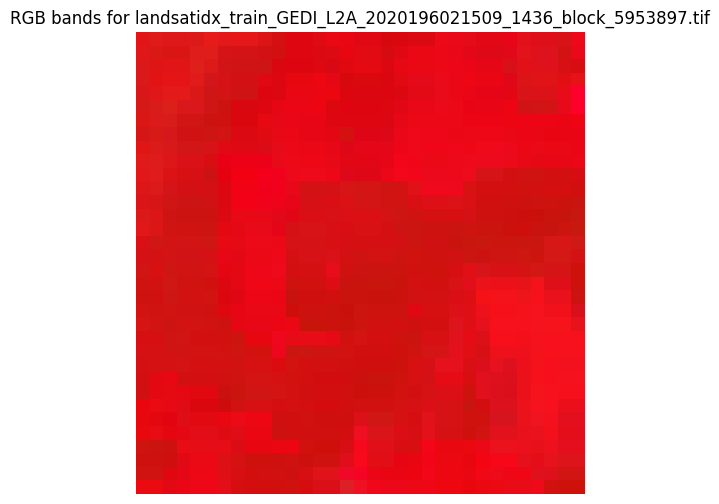

In [146]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt

for fname in sample_files:
    fpath = os.path.join(RASTER_DIR, fname)

    print("\n" + "="*80)
    print("FILE:", fname)

    with rasterio.open(fpath) as src:
        width = src.width
        height = src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {transform.e*-1} (approx meters)")

        # Loop over bands for stats
        for b in range(1, count + 1):
            data = src.read(b)
            data = data.astype(float)  # ensure numeric

            # Mask nodata
            if src.nodata is not None:
                data = np.where(data == src.nodata, np.nan, data)

            band_min = np.nanmin(data)
            band_max = np.nanmax(data)
            band_mean = np.nanmean(data)
            band_std = np.nanstd(data)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {band_min}")
            print(f"      max:  {band_max}")
            print(f"      mean: {band_mean}")
            print(f"      std:  {band_std}")

        # --- Visualization ---
        plt.figure(figsize=(6, 6))
        if count >= 3:
            # Read the first three bands for RGB visualization
            img = src.read([1, 2, 3]).transpose(1, 2, 0)

            # Normalize for display (min-max)
            img = (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)
            plt.imshow(img)
            plt.title(f"RGB bands for {fname}")
        elif count == 1:
            # Read the single band for grayscale visualization
            img = src.read(1)
            plt.imshow(img, cmap='gray')
            plt.title(f"Grayscale band for {fname}")
        else:
            print(f"Skipping visualization for {fname}: not enough bands for RGB or single band.")

        plt.axis('off')
        plt.show()

# Prep tifs: Pad, Normalize, inspect, save to content

In [149]:
import os

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Output directory:", PROCESSED_DIR)


Output directory: /content/processed_32x32_normalized


In [150]:
from rasterio.enums import Resampling

def resize_to_max32(src):
    """
    Resize rasterio dataset to ensure h,w <= 32 while preserving aspect ratio.
    Returns a numpy array (bands, new_h, new_w).
    """
    h = src.height
    w = src.width
    bands = src.count

    # No resizing needed
    if h <= 32 and w <= 32:
        return src.read()

    scale_h = 32 / h
    scale_w = 32 / w
    scale = min(scale_h, scale_w)

    new_h = max(1, int(h * scale))
    new_w = max(1, int(w * scale))

    resized = src.read(
        out_shape=(bands, new_h, new_w),
        resampling=Resampling.bilinear
    )

    return resized


In [151]:
import numpy as np

def pad_to_32x32(arr):
    """Center-pad a raster to exactly (bands, 32, 32)."""
    bands, h, w = arr.shape
    padded = np.zeros((bands, 32, 32), dtype=arr.dtype)

    h_start = (32 - h) // 2
    w_start = (32 - w) // 2

    padded[:, h_start:h_start+h, w_start:w_start+w] = arr
    return padded


In [27]:
def minmax_normalize(arr):
    arr = arr.astype(float)
    for b in range(arr.shape[0]):
        mn = np.nanmin(arr[b])
        mx = np.nanmax(arr[b])
        arr[b] = (arr[b] - mn) / (mx - mn + 1e-9)
    return arr


In [160]:
import rasterio
import numpy as np
import os

# -------------------------------------------------------------------------
# 1. QUALITY CHECK: only scan TIFFs in PROCESSED_DIR
# -------------------------------------------------------------------------

PROCESSED_DIR = "/content/processed_32x32_normalized"
os.makedirs(PROCESSED_DIR, exist_ok=True)

print("Scanning directory:", PROCESSED_DIR)

all_tifs = [
    f for f in os.listdir(PROCESSED_DIR)
    if f.lower().endswith((".tif", ".tiff"))
]

total_files = len(all_tifs)
corrected_files = 0
dropped_files = 0

print(f"\nFound {total_files} TIFFs in {PROCESSED_DIR}\n")

selected_files = []   # <-- Files that pass checks
dropped_list = []     # <-- Files to delete


for fname in all_tifs:
    fpath = os.path.join(PROCESSED_DIR, fname)

    with rasterio.open(fpath) as src:
        bands = []
        needs_correction = False
        too_many_nans = False

        for b in range(1, src.count + 1):
            data = src.read(b).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

            nan_count = np.isnan(data).sum()

            if nan_count > 0:
                needs_correction = True
            if nan_count >= 100:
                too_many_nans = True

            bands.append(data)

    # Drop files with too many NaNs
    if too_many_nans:
        dropped_files += 1
        dropped_list.append(fname)     # <--- NOW correctly recorded
        print(f"DROPPED: {fname} (≥100 NaNs)")
        continue

    # Fix files that have ≤99 NaNs
    if needs_correction:
        corrected_files += 1
        print(f"FIXING: {fname} (median fill)")

        cleaned_bands = []
        for data in bands:
            if np.isnan(data).any():
                med = np.nanmedian(data)
                data = np.where(np.isnan(data), med, data)
            cleaned_bands.append(data)

        # Write cleaned TIFF back to disk
        with rasterio.open(fpath) as src:
            profile = src.profile

        with rasterio.open(fpath, "w", **profile) as dst:
            for i, band in enumerate(cleaned_bands, start=1):
                dst.write(band.astype(profile["dtype"]), i)

    # Keep this TIFF for further processing
    selected_files.append(fname)

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------
print("\n" + "="*60)
print("TIFF QUALITY CHECK SUMMARY")
print(f"Total TIFFs scanned           : {total_files}")
print(f"TIFFs corrected (median fill) : {corrected_files}")
print(f"TIFFs dropped (≥100 NaNs)     : {dropped_files}")
print(f"TIFFs passed to processing    : {len(selected_files)}")
print("="*60 + "\n")

print("Dropped files:", dropped_list)

# -------------------------------------------------------------------------
# DELETE DROPPED FILES
# -------------------------------------------------------------------------
print("\nDeleting dropped TIFF files...\n")

for fname in dropped_list:
    fpath = os.path.join(PROCESSED_DIR, fname)
    if os.path.exists(fpath):
        os.remove(fpath)
        print("Deleted:", fname)

print("\nFinished deleting dropped TIFFs.")
print("Total deleted files:", len(dropped_list))


Scanning directory: /content/processed_32x32_normalized

Found 1928 TIFFs in /content/processed_32x32_normalized

DROPPED: hls_train_GEDI_L2A_2021135083748_1476_block_5923899.tif (≥100 NaNs)
DROPPED: s2_test_GEDI_L2A_2022139064237_231_block_5933887.tif (≥100 NaNs)
DROPPED: hls_test_GEDI_L2A_2021135083748_190_block_6033892.tif (≥100 NaNs)
DROPPED: tcap_train_GEDI_L2A_2022358084911_713_block_5923888.tif (≥100 NaNs)
DROPPED: landsatidx_test_GEDI_L2A_2022139064237_231_block_5933887.tif (≥100 NaNs)
DROPPED: landsatidx_train_GEDI_L2A_2021135083748_50_block_5953899.tif (≥100 NaNs)
DROPPED: landsat_train_GEDI_L2A_2021135083748_681_block_6033891.tif (≥100 NaNs)
DROPPED: hls_train_GEDI_L2A_2022358084911_1190_block_5923887.tif (≥100 NaNs)
DROPPED: hls_test_GEDI_L2A_2021135083748_191_block_6033892.tif (≥100 NaNs)
DROPPED: s2_train_GEDI_L2A_2022358084911_1367_block_6033898.tif (≥100 NaNs)
DROPPED: landsatidx_test_GEDI_L2A_2021135083748_191_block_6033892.tif (≥100 NaNs)
DROPPED: hls_train_GEDI_L2A_2

In [162]:
processed_paths = {}

for fname in selected_files:
    src_path = os.path.join(PROCESSED_DIR, fname)
    out_path = os.path.join(PROCESSED_DIR, fname)   # overwrite or change if desired

    with rasterio.open(src_path) as src:

        # Step 1: Resize
        resized = resize_to_max32(src)

        # Step 2: Pad
        padded = pad_to_32x32(resized)

        # Step 3: Normalize
        normalized = minmax_normalize(padded)

        # Write raster
        profile = src.profile
        profile.update({
            "height": 32,
            "width": 32,
            "transform": rasterio.transform.from_origin(0, 0, 1, 1),
            "dtype": "float32"
        })

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(normalized.astype("float32"))

    processed_paths[fname] = out_path

print("Processed", len(processed_paths), "TIFFs successfully.")


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


Processed 1735 TIFFs successfully.


comp. before preprocessing

In [163]:
processed_sample_files = {}

for fname in sample_files:
    processed_path = os.path.join(PROCESSED_DIR, fname)

    if os.path.exists(processed_path):
        processed_sample_files[fname] = processed_path
    else:
        print(f"⚠️ WARNING: Processed version not found for {fname}")



PROCESSED FILE: hls_train_GEDI_L2A_2022139064237_695_block_5923888.tif
LOCATION: /content/processed_32x32_normalized/hls_train_GEDI_L2A_2022139064237_695_block_5923888.tif
BANDS: 7
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6816949738968106
      std:  0.17101680259250587

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.29160063050449025
      std:  0.14438995974771354

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5662567161634797
      std:  0.16697545343706036

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5700099897840119
      std:  0.1631748433636319

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6257674247208342
      std:  0.14382303748800274

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3742325698603963
      std:  0.1438230375885169

  Band 7 statistics:
      min: 

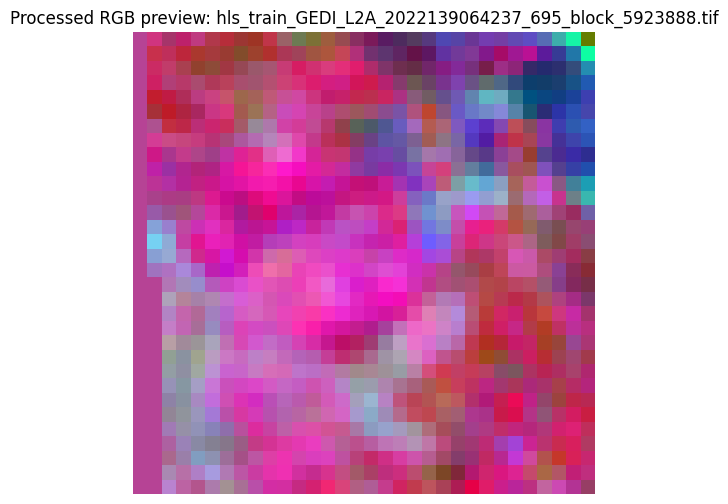


PROCESSED FILE: landsatidx_train_GEDI_L2A_2021135083748_512_block_5953899.tif
LOCATION: /content/processed_32x32_normalized/landsatidx_train_GEDI_L2A_2021135083748_512_block_5953899.tif
BANDS: 7
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6726883802784869
      std:  0.1785946246675749

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3494031801510573
      std:  0.15895440370891167

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4076758797364164
      std:  0.16233498141462552

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3979416436795873
      std:  0.15913737968927288

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4615631221950025
      std:  0.17836177913137571

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5384368755494506
      std:  0.17836178060223679

  Band 7 statistic

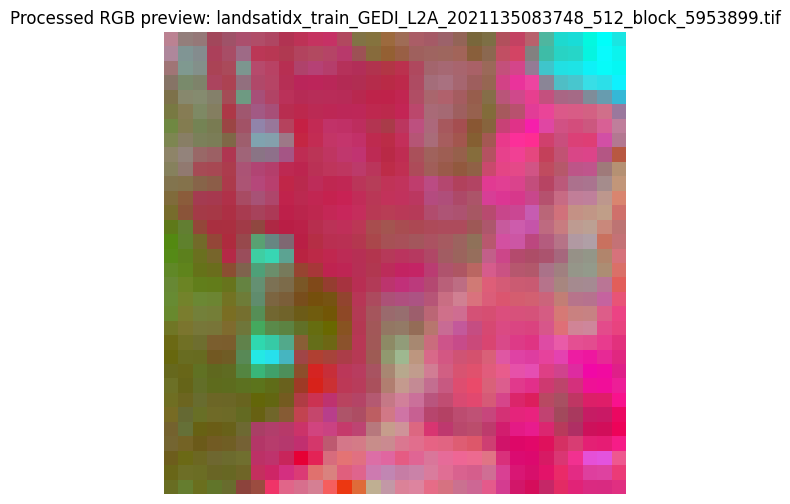


PROCESSED FILE: landsat_train_GEDI_L2A_2020196021509_484_block_5943899.tif
LOCATION: /content/processed_32x32_normalized/landsat_train_GEDI_L2A_2020196021509_484_block_5943899.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4822568564231915
      std:  0.20236179066127602

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.46752204702079325
      std:  0.14077117496006908

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.32158825677106506
      std:  0.11830731373033368

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.47611657474772073
      std:  0.16158527811244838

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5737191444641212
      std:  0.1704063337739073

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4832359983092829
      std:  0.18984404279253536


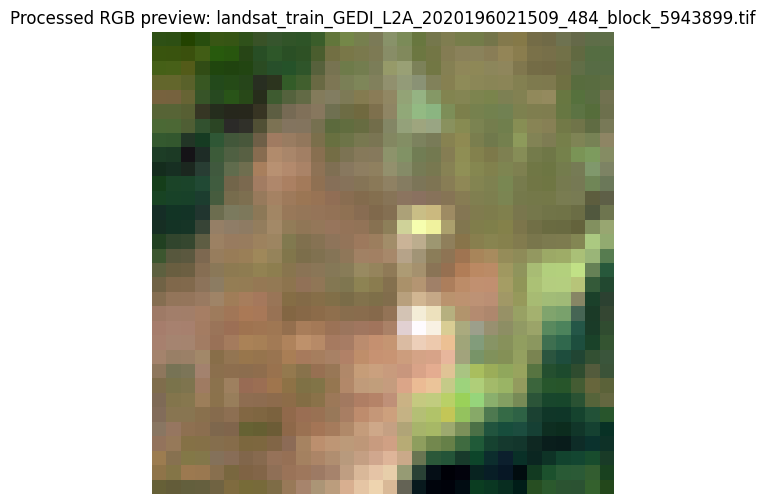


PROCESSED FILE: landsat_train_GEDI_L2A_2020196021509_1434_block_5953897.tif
LOCATION: /content/processed_32x32_normalized/landsat_train_GEDI_L2A_2020196021509_1434_block_5953897.tif
BANDS: 6
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4993694031062432
      std:  0.1951477453498651

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5248228436903446
      std:  0.12195765746313116

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5291266935237218
      std:  0.15674793707879034

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.4315461090372992
      std:  0.17715802730774705

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5515244273265125
      std:  0.15219319848815868

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.5249282703152858
      std:  0.19456878863604177


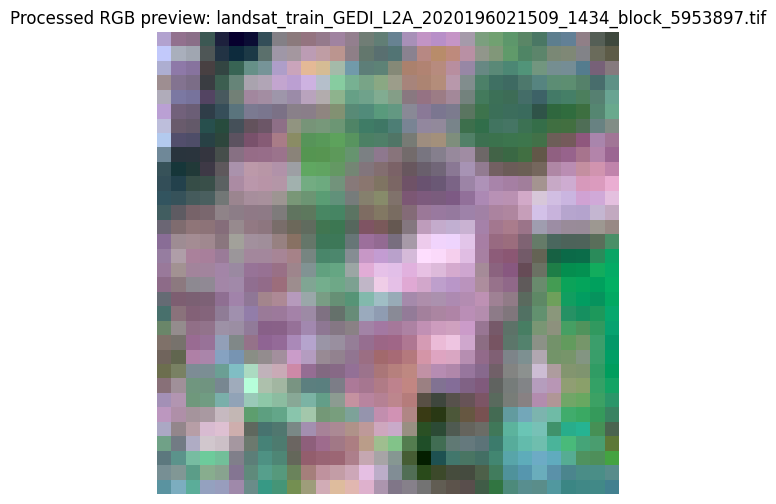


PROCESSED FILE: landsatidx_train_GEDI_L2A_2020196021509_1436_block_5953897.tif
LOCATION: /content/processed_32x32_normalized/landsatidx_train_GEDI_L2A_2020196021509_1436_block_5953897.tif
BANDS: 7
SIZE (pixels): 32 x 32
TOTAL PIXELS: 1024
SPATIAL RESOLUTION: 1.0 x 1.0 (arbitrary)

  Band 1 statistics:
      min:  0.0
      max:  1.0
      mean: 0.7408077482832596
      std:  0.1589962777802637

  Band 2 statistics:
      min:  0.0
      max:  1.0
      mean: 0.14168450310290837
      std:  0.16039521392323347

  Band 3 statistics:
      min:  0.0
      max:  1.0
      mean: 0.11515431486077432
      std:  0.16352706628865113

  Band 4 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6650743002828676
      std:  0.16162340554838092

  Band 5 statistics:
      min:  0.0
      max:  1.0
      mean: 0.3223413791783969
      std:  0.14968772239217829

  Band 6 statistics:
      min:  0.0
      max:  1.0
      mean: 0.6776586207124637
      std:  0.1496877236880518

  Band 7 statis

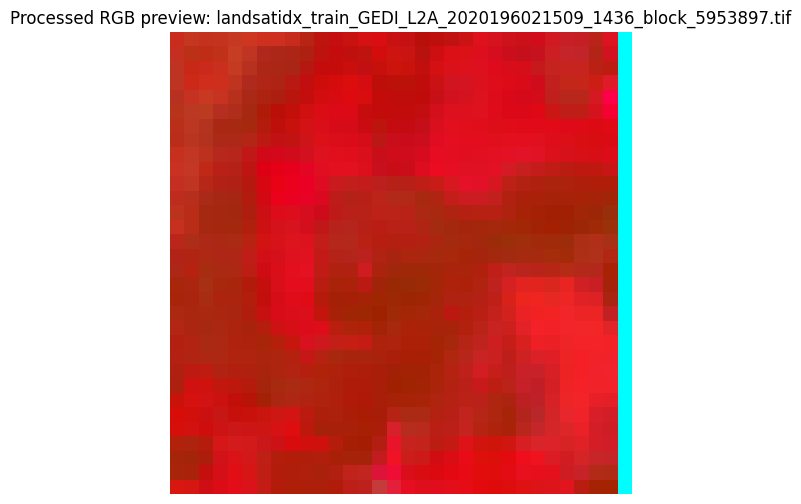

In [164]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

for fname, fpath in processed_sample_files.items():

    print("\n" + "="*80)
    print("PROCESSED FILE:", fname)
    print("LOCATION:", fpath)

    with rasterio.open(fpath) as src:
        width, height = src.width, src.height
        count = src.count
        transform = src.transform

        print(f"BANDS: {count}")
        print(f"SIZE (pixels): {width} x {height}")
        print(f"TOTAL PIXELS: {width * height}")
        print(f"SPATIAL RESOLUTION: {transform.a} x {abs(transform.e)} (arbitrary)")

        # ---- Band statistics ----
        for b in range(1, count + 1):
            data = src.read(b).astype(float)

            print(f"\n  Band {b} statistics:")
            print(f"      min:  {np.nanmin(data)}")
            print(f"      max:  {np.nanmax(data)}")
            print(f"      mean: {np.nanmean(data)}")
            print(f"      std:  {np.nanstd(data)}")

        # ---- Visualization ----
        plt.figure(figsize=(6, 6))

        if count >= 3:
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
            plt.imshow(img)
            plt.title(f"Processed RGB preview: {fname}")

        else:
            img = src.read(1)
            plt.imshow(img, cmap="gray")
            plt.title(f"Processed grayscale preview: {fname}")

        plt.axis("off")
        plt.show()


# Target filter

In [165]:
import pandas as pd

GEDI_CSV = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/GEDI_L2A_L2B_L1B_merged_11_3_25_with_blocks_splits.csv"

# Load CSV
df = pd.read_csv(GEDI_CSV)

# Filter for product_field == "GEDI_LSA"
df_filtered_GEDI_L2A = df[df["product_field"] == "GEDI_L2A"]

df_filtered_GEDI_L2A


/tmp/ipython-input-686974334.py:6: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(GEDI_CSV)


,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,pavd_z_bin_9,stale_return_flag,pai_z_bin_4,x,y,block_x,block_y,block_id,row_ID,split
0,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214071,-85.989695,455.898773,470.743774,-18.850618,0.977285,0.0,1.0,...,NaN,NaN,NaN,591952.855432,3.897251e+06,591,3897,591_3897,1,train
1,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.214767,-85.988777,459.104523,467.231506,-18.850683,0.990288,0.0,1.0,...,NaN,NaN,NaN,592035.619870,3.897329e+06,592,3897,592_3897,2,val
2,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215471,-85.987846,449.121246,455.059265,-18.850748,0.989432,0.0,1.0,...,NaN,NaN,NaN,592119.554656,3.897408e+06,592,3897,592_3897,3,val
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,NaN,NaN,NaN,592159.115617,3.897445e+06,592,3897,592_3897,4,val
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.216501,-85.986494,478.569794,489.838898,-18.850840,0.981278,0.0,1.0,...,NaN,NaN,NaN,592241.425190,3.897523e+06,592,3897,592_3897,5,val
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1863,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217155,-85.859947,549.746216,567.769958,-41.230606,0.977462,0.0,1.0,...,NaN,NaN,NaN,603758.425670,3.897721e+06,603,3897,603_3897,1864,train
1864,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217505,-85.859484,550.669312,566.905273,-41.230209,0.975680,0.0,1.0,...,NaN,NaN,NaN,603800.146408,3.897760e+06,603,3897,603_3897,1865,train
1865,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.217854,-85.859021,549.173706,566.905273,-41.229813,0.978489,0.0,1.0,...,NaN,NaN,NaN,603841.799971,3.897799e+06,603,3897,603_3897,1866,train
1866,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,NaN,NaN,NaN,603925.187830,3.897878e+06,603,3897,603_3897,1867,train


# Pair Tif and GEDI Obs (Targets)

In [166]:
import re

FILENAME_RE = re.compile(
    r"^(?P<cov>[a-zA-Z0-9]+)_"          # covariate (s1, s2, landsatidx, etc)
    r"(?P<split>train|test|val)_"       # split
    r"GEDI_L2A_"                        # product field (constant)
    r"(?P<shot>\d+)_"                   # shot
    r"(?P<row_ID>\d+)_"                 # row_ID
    r"block_(?P<block_id>\d+)\.tif$"    # block_id
)


In [167]:
import os
import pandas as pd

TIFF_ROOT = "/content/processed_32x32_normalized"

rows = []

for fn in os.listdir(TIFF_ROOT):
    if not fn.endswith(".tif"):
        continue

    m = FILENAME_RE.match(fn)
    if m is None:
        print("WARNING: filename did not match pattern:", fn)
        continue

    d = m.groupdict()
    d["filename"] = fn
    d["full_path"] = os.path.join(TIFF_ROOT, fn)
    rows.append(d)

tif_df = pd.DataFrame(rows)
print("Parsed TIFFs:", len(tif_df))
print(tif_df.head())


Parsed TIFFs: 1735
       cov  split           shot row_ID block_id  \
0       s1   test  2021135083748    161  6013894   
1    s2idx  train  2020196021509    958  5933896   
2  landsat  train  2022358084911    287  5943891   
3      dem  train  2022358084911    886  6023898   
4       s1  train  2022358084911    851  6003896   

                                            filename  \
0  s1_test_GEDI_L2A_2021135083748_161_block_60138...   
1  s2idx_train_GEDI_L2A_2020196021509_958_block_5...   
2  landsat_train_GEDI_L2A_2022358084911_287_block...   
3  dem_train_GEDI_L2A_2022358084911_886_block_602...   
4  s1_train_GEDI_L2A_2022358084911_851_block_6003...   

                                           full_path  
0  /content/processed_32x32_normalized/s1_test_GE...  
1  /content/processed_32x32_normalized/s2idx_trai...  
2  /content/processed_32x32_normalized/landsat_tr...  
3  /content/processed_32x32_normalized/dem_train_...  
4  /content/processed_32x32_normalized/s1_train_G...  


In [168]:
print("\nTIFF counts per covariate:")
print(tif_df["cov"].value_counts())



TIFF counts per covariate:
cov
dem           260
landsat       260
tcap          260
landsatidx    260
hls           259
s1            237
s2idx         137
s2             62
Name: count, dtype: int64


In [169]:
df_filtered_GEDI_L2A["row_ID"] = df_filtered_GEDI_L2A["row_ID"].astype(int)
tif_df["row_ID"] = tif_df["row_ID"].astype(int)

merged = df_filtered_GEDI_L2A.merge(tif_df, on="row_ID", how="left")


/tmp/ipython-input-1886280410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_GEDI_L2A["row_ID"] = df_filtered_GEDI_L2A["row_ID"].astype(int)


In [170]:
valid = merged[~merged["filename"].isna()]
print("GEDI L2A rows:", len(df_filtered_GEDI_L2A))
print("Rows with matching TIFFs:", len(valid["row_ID"].unique()))


GEDI L2A rows: 1868
Rows with matching TIFFs: 283


In [73]:
df_valid = pd.DataFrame(valid)

In [74]:
df_valid

,beam,source_file,lat,lon,elev_lowestmode,digital_elevation_model,solar_elevation,sensitivity,degrade_flag,quality_flag,...,block_y,block_id_x,row_ID,split_x,cov,split_y,shot,block_id_y,filename,full_path
3,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,s1,val,2020196021509,5923897,s1_val_GEDI_L2A_2020196021509_4_block_5923897.tif,/content/processed_32x32_normalized/s1_val_GED...
4,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,landsat,val,2020196021509,5923897,landsat_val_GEDI_L2A_2020196021509_4_block_592...,/content/processed_32x32_normalized/landsat_va...
5,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,landsatidx,val,2020196021509,5923897,landsatidx_val_GEDI_L2A_2020196021509_4_block_...,/content/processed_32x32_normalized/landsatidx...
6,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,tcap,val,2020196021509,5923897,tcap_val_GEDI_L2A_2020196021509_4_block_592389...,/content/processed_32x32_normalized/tcap_val_G...
7,BEAM0101,118699863_GEDI02_A_2020196021509_O08987_02_T05...,35.215807,-85.987407,470.780426,477.108856,-18.850777,0.990889,0.0,1.0,...,3897,592_3897,4,val,dem,val,2020196021509,5923897,dem_val_GEDI_L2A_2020196021509_4_block_5923897...,/content/processed_32x32_normalized/dem_val_GE...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3496,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,tcap,train,2022358084911,6033897,tcap_train_GEDI_L2A_2022358084911_1867_block_6...,/content/processed_32x32_normalized/tcap_train...
3497,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,dem,train,2022358084911,6033897,dem_train_GEDI_L2A_2022358084911_1867_block_60...,/content/processed_32x32_normalized/dem_train_...
3498,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,landsat,train,2022358084911,6033897,landsat_train_GEDI_L2A_2022358084911_1867_bloc...,/content/processed_32x32_normalized/landsat_tr...
3499,BEAM1011,118715087_GEDI02_A_2022358084911_O22836_02_T06...,35.218554,-85.858095,549.621399,568.409729,-41.229019,0.976131,0.0,1.0,...,3897,603_3897,1867,train,landsatidx,train,2022358084911,6033897,landsatidx_train_GEDI_L2A_2022358084911_1867_b...,/content/processed_32x32_normalized/landsatidx...


In [75]:
# df_valid.to_csv('df_valid.csv', index=False)

In [59]:
column_names = valid.columns.tolist()
print(column_names)

['beam', 'source_file', 'lat', 'lon', 'elev_lowestmode', 'digital_elevation_model', 'solar_elevation', 'sensitivity', 'degrade_flag', 'quality_flag', 'num_detectedmodes', 'rh', 'dem_diff', 'product_field', 'shot_number', 'cover_z_bin_21', 'pai_z_bin_5', 'pai_z_bin_23', 'pai_z_bin_8', 'pai_z_bin_18', 'pavd_z_bin_6', 'cover_z_bin_12', 'pai_z_bin_24', 'pai_z_bin_17', 'pavd_z_bin_1', 'pavd_z_bin_10', 'rx_energy', 'pavd_z_bin_11', 'pavd_z_bin_20', 'cover_z_bin_10', 'pai_z_bin_16', 'cover_z_bin_22', 'cover_z_bin_27', 'pavd_z_bin_28', 'pavd_z_bin_4', 'pai_z_bin_22', 'pavd_z_bin_19', 'pavd_z_bin_2', 'elevation_bin0', 'pai', 'pai_z_bin_14', 'pai_z_bin_3', 'degrade', 'cover_z_bin_28', 'rhog', 'cover_z_bin_29', 'pai_z_bin_21', 'cover_z_bin_4', 'cover_z_bin_23', 'pavd_z_bin_7', 'cover_z_bin_26', 'cover_z_bin_1', 'pavd_z_bin_27', 'rhov', 'pavd_z_bin_23', 'pavd_z_bin_0', 'pai_z_bin_25', 'l2b_quality_flag', 'fhd_normal', 'pai_z_bin_12', 'pavd_z_bin_21', 'pavd_z_bin_22', 'cover_z_bin_0', 'pgap_theta',

In [171]:
eo_list = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']

print("\nCounts per EO by split:")
for eo in eo_list:
    eo_df = tif_df[tif_df["cov"] == eo]
    print(f"\nEO = {eo}")
    print(eo_df["split"].value_counts())



Counts per EO by split:

EO = s1
split
train    165
test      48
val       24
Name: count, dtype: int64

EO = s2
split
train    39
test     23
Name: count, dtype: int64

EO = landsat
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = landsatidx
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = hls
split
train    193
test      42
val       24
Name: count, dtype: int64

EO = tcap
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = dem
split
train    194
test      42
val       24
Name: count, dtype: int64

EO = s2idx
split
train    104
test      22
val       11
Name: count, dtype: int64


# Data loaders

In [172]:
EO_LIST = ['s1', 's2', 'landsat', 'landsatidx', 'hls', 'tcap', 'dem', 's2idx']
SPATIAL_RES = {
    's1': 10, 's2': 20, 's2idx': 20,
    'landsat': 30, 'landsatidx': 30,
    'hls': 30, 'tcap': 30, 'dem': 30
}
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

In [173]:
import torch
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import random


# -----------------------
# Remove NaN samples
# -----------------------
def drop_nan_samples(df):
    clean_rows = []
    dropped = 0

    for i, row in df.iterrows():
        fp = row["full_path"]
        try:
            with rasterio.open(fp) as src:
                arr = src.read().astype(np.float32)
                if np.isnan(arr).any():
                    dropped += 1
                    continue
        except:
            dropped += 1
            continue

        clean_rows.append(row)

    clean_df = pd.DataFrame(clean_rows).reset_index(drop=True)
    print(f"\n[CLEAN] Removed {dropped} NaN samples. Remaining: {len(clean_df)}")
    return clean_df

# -----------------------
# Dataset for a single EO
# -----------------------
class GeoTiffDataset(Dataset):
    def __init__(self, df, eo, bands_per_cov, target_col='rh', transform=None, augment=False, split='train'):
        """
        Single-EO Dataset for multibranch model.
        df: pandas DataFrame
        eo: EO type (string, must match 'cov' column)
        bands_per_cov: dict mapping EO type to number of bands
        target_col: target column name
        transform: optional transform
        augment: whether to apply flips and rotations
        split: data partition ('train', 'val', 'test')
        """
        # Filter rows by EO and split
        self.df = df[(df['cov'] == eo) & (df['split_x'] == split)].reset_index(drop=True)
        self.eo = eo
        self.bands = bands_per_cov[eo]
        self.target_col = target_col
        self.transform = transform
        self.augment = augment

        if len(self.df) == 0:
            print(f"[WARNING] Dataset for EO '{eo}' and split '{split}' initialized with 0 samples!")
        else:
            print(f"[INFO] Dataset for EO '{eo}' and split '{split}' initialized with {len(self.df)} samples")
        print(f"[INFO] Target column: {self.target_col}")
        print(f"[INFO] Augmentation enabled: {self.augment}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fp = row['full_path']

        with rasterio.open(fp) as src:
            arr = src.read().astype(np.float32)  # (C, H, W)

        # Verify band count
        if arr.shape[0] != self.bands:
            raise ValueError(f"EO {self.eo} at idx {idx} has {arr.shape[0]} bands, expected {self.bands}")

        # Augmentation: flips and rotations
        if self.augment:
            if random.random() > 0.5:  # horizontal flip
                arr = arr[:, :, ::-1].copy()
            if random.random() > 0.5:  # vertical flip
                arr = arr[:, ::-1, :].copy()
            k = random.randint(0, 3)
            arr = np.rot90(arr, k, axes=(1, 2)).copy()

        if self.transform:
            arr = self.transform(arr)

        x = torch.tensor(arr, dtype=torch.float32)
        y = torch.tensor(row[self.target_col], dtype=torch.float32)

        return x, y

# -----------------------
# Function to create loaders per EO and split
# -----------------------
def create_multibranch_loaders(df, eo_list, bands_per_cov, target_col='rh', batch_size=16, augment=False, split='train'):
    """
    Create a dictionary of DataLoaders per EO.
    Returns: dict {eo: DataLoader}
    """
    loaders = {}
    for eo in eo_list:
        dataset = GeoTiffDataset(df, eo, bands_per_cov, target_col=target_col, augment=augment, split=split)
        if len(dataset) == 0:
            print(f"[WARNING] Skipping EO '{eo}' because dataset is empty for split '{split}'")
            continue
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=(split=='train'), num_workers=2)
        loaders[eo] = loader
        print(f"[INFO] DataLoader for EO '{eo}' created with {len(loader)} batches, batch size {batch_size}")
    return loaders

# -----------------------
# Example usage: create loaders for all EO branches for 'train' split
# -----------------------
EO_LIST = ['s1','s2','landsat','landsatidx','hls','tcap','dem','s2idx']
BANDS_PER_COV = {
    's1': 4, 's2': 6, 's2idx': 8,
    'landsat': 6, 'landsatidx': 7, 'hls': 7, 'tcap': 6, 'dem': 2
}

train_loaders = create_multibranch_loaders(valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=True, split='train')

# -----------------------
# Inspect first batch per EO
# -----------------------
for eo, loader in train_loaders.items():
    first_sample, first_target = next(iter(loader))
    print(f"\n[INFO] EO branch: {eo}")
    print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
    print(f"  Target shape: {first_target.shape}")  # (B,)


[INFO] Dataset for EO 's1' and split 'train' initialized with 165 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's1' created with 11 batches, batch size 16
[INFO] Dataset for EO 's2' and split 'train' initialized with 39 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 's2' created with 3 batches, batch size 16
[INFO] Dataset for EO 'landsat' and split 'train' initialized with 194 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsat' created with 13 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'train' initialized with 194 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'landsatidx' created with 13 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'train' initialized with 193 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: True
[INFO] DataLoader for EO 'hls' cre

In [190]:
# -----------------------
# Test loaders without augmentation
# -----------------------
test_loaders = create_multibranch_loaders(
    valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='test'
)

# -----------------------
# Inspect first batch per EO for TEST
# -----------------------
print("\n==================== TEST LOADERS ====================")
for eo, loader in test_loaders.items():
    first_sample, first_target = next(iter(loader))
    print(f"\n[INFO] Split: TEST | EO branch: {eo}")
    print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
    print(f"  Target shape: {first_target.shape}")  # (B,)



# -----------------------
# Validation loaders without augmentation
# -----------------------
val_loaders = create_multibranch_loaders(
    valid, EO_LIST, BANDS_PER_COV, target_col='rh', batch_size=16, augment=False, split='val'
)

# -----------------------
# Inspect first batch per EO for VAL
# -----------------------
print("\n==================== VAL LOADERS ====================")
for eo, loader in val_loaders.items():
    first_sample, first_target = next(iter(loader))
    print(f"\n[INFO] Split: VAL | EO branch: {eo}")
    print(f"  Sample shape: {first_sample.shape}")  # (B, C, H, W)
    print(f"  Target shape: {first_target.shape}")  # (B,)



[INFO] Dataset for EO 's1' and split 'val' initialized with 24 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 's1' created with 2 batches, batch size 16
[WARNING] Dataset for EO 's2' and split 'val' initialized with 0 samples!
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[WARNING] Skipping EO 's2' because dataset is empty for split 'val'
[INFO] Dataset for EO 'landsat' and split 'val' initialized with 24 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsat' created with 2 batches, batch size 16
[INFO] Dataset for EO 'landsatidx' and split 'val' initialized with 24 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'landsatidx' created with 2 batches, batch size 16
[INFO] Dataset for EO 'hls' and split 'val' initialized with 24 samples
[INFO] Target column: rh
[INFO] Augmentation enabled: False
[INFO] DataLoader for EO 'hls' created with

check for NAN

In [189]:
# -----------------------
# Check datasets + loaders for NaN values
# -----------------------

def check_nans_in_dataset(df, eo_list):
    print("\n========== DATASET NaN CHECK ==========")
    import rasterio
    import numpy as np

    for eo in eo_list:
        subdf = df[df["cov"] == eo]
        if len(subdf) == 0:
            print(f"[INFO] EO '{eo}' has no rows in dataframe.")
            continue

        nan_files = []
        for _, row in subdf.iterrows():
            fp = row["full_path"]
            try:
                with rasterio.open(fp) as src:
                    arr = src.read().astype(np.float32)
                    if np.isnan(arr).any():
                        nan_files.append(fp)
            except Exception as e:
                print(f"[ERROR] Could not read {fp}: {e}")

        if len(nan_files) > 0:
            print(f"[WARNING] EO '{eo}' has {len(nan_files)} files containing NaN.")
            for f in nan_files[:5]:  # show first 5
                print("    ", f)
        else:
            print(f"[OK] EO '{eo}' has no NaN values in any raster.")

def check_nans_in_loaders(loaders):
    print("\n========== LOADER NaN CHECK ==========")
    import torch

    for eo, loader in loaders.items():
        try:
            batch_x, batch_y = next(iter(loader))
        except StopIteration:
            print(f"[WARNING] EO '{eo}' loader is empty.")
            continue

        x_nan = torch.isnan(batch_x).any().item()
        y_nan = torch.isnan(batch_y).any().item()

        if x_nan or y_nan:
            print(f"[WARNING] NaNs found in first batch of EO '{eo}'")
            print(f"   NaN in inputs: {x_nan}")
            print(f"   NaN in targets: {y_nan}")
        else:
            print(f"[OK] EO '{eo}' first batch has no NaNs.")

# ---------- RUN CHECKS ----------
check_nans_in_dataset(valid, EO_LIST)
check_nans_in_loaders(train_loaders)



========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.


KeyboardInterrupt: 

In [191]:
# -----------------------
# Run NaN checks across all splits
# -----------------------
splits = ['train', 'val', 'test']
loaders_dict = {
    'train': train_loaders,
    'val': val_loaders,
    'test': test_loaders
}

for split in splits:
    print(f"\n==================== NaN CHECK: {split.upper()} ====================")

    # Check dataset
    check_nans_in_dataset(valid[valid['split_x'] == split], EO_LIST)

    # Check loaders
    check_nans_in_loaders(loaders_dict[split])



==================== NaN CHECK: TRAIN ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[OK] EO 's2' has no NaN values in any raster.
[OK] EO 'landsat' has no NaN values in any raster.
[OK] EO 'landsatidx' has no NaN values in any raster.
[OK] EO 'hls' has no NaN values in any raster.
[OK] EO 'tcap' has no NaN values in any raster.
[OK] EO 'dem' has no NaN values in any raster.
[OK] EO 's2idx' has no NaN values in any raster.

========== LOADER NaN CHECK ==========
[OK] EO 's1' first batch has no NaNs.
[OK] EO 's2' first batch has no NaNs.
[OK] EO 'landsat' first batch has no NaNs.
[OK] EO 'landsatidx' first batch has no NaNs.
[OK] EO 'hls' first batch has no NaNs.
[OK] EO 'tcap' first batch has no NaNs.
[OK] EO 'dem' first batch has no NaNs.
[OK] EO 's2idx' first batch has no NaNs.

==================== NaN CHECK: VAL ====================

========== DATASET NaN CHECK ==========
[OK] EO 's1' has no NaN values in any raster.
[I

# GEDI L1B Autoendcoder and dataset and loader construction

In [176]:
import numpy as np

file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'

# Load with allow_pickle=True
arr = np.load(file_path, allow_pickle=True)

# Check if any NaN exists
# For object arrays, np.isnan might not work directly, so use a comprehension
has_nan = any(np.isnan(x) if isinstance(x, (int, float, np.number)) else False for x in arr.flatten())

print("Any NaN values?", has_nan)

# Count NaNs
num_nan = sum(1 for x in arr.flatten() if isinstance(x, (int, float, np.number)) and np.isnan(x))
print("Number of NaN values:", num_nan)


Any NaN values? False
Number of NaN values: 0


In [177]:
import numpy as np
import torch
from torch.utils.data import Dataset

# 1️⃣ Load the .npy file
file_path = '/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project/GEDI_target/npy_full_GEDIL1B/GEDI_L1B_Merged_NPY.npy'
data = np.load(file_path, allow_pickle=True).item()  # actual_data = data.item()

# 2️⃣ Inspect keys if it’s a dict
print("Keys in the .npy object:", list(data.keys()))

# Assuming the waveform data is under the key 'rxwaveform' (adjust if different)
waveforms = data['rxwaveform']  # should be a list or array of arrays

# 3️⃣ Define a PyTorch Dataset
class RxWaveformDataset(Dataset):
    def __init__(self, waveforms, transform=None, fixed_length=None):
        self.transform = transform
        self.fixed_length = fixed_length
        self.data = []

        for wf in waveforms:
            arr = np.array(wf, dtype=np.float32)

            # Pad or truncate to fixed length if specified
            if fixed_length is not None:
                if len(arr) < fixed_length:
                    arr = np.pad(arr, (0, fixed_length - len(arr)), mode='constant')
                else:
                    arr = arr[:fixed_length]

            self.data.append(arr)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        waveform = self.data[idx]
        if self.transform:
            waveform = self.transform(waveform)
        return torch.tensor(waveform, dtype=torch.float32)

# 4️⃣ Create the dataset
dataset_rx = RxWaveformDataset(waveforms, fixed_length=1024)  # adjust fixed_length if needed
print("Number of waveforms:", len(dataset_rx))
print("Shape of first waveform:", dataset_rx[0].shape)


Keys in the .npy object: ['latitude_bin0', 'longitude_bin0', 'shot_number', 'degrade', 'stale_return_flag', 'elevation_bin0', 'rxwaveform', 'rx_energy', 'rx_sample_count', 'rx_sample_start_index', 'solar_elevation', 'digital_elevation_model']
Number of waveforms: 3846
Shape of first waveform: torch.Size([1024])


# Modeling

In [183]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PatchEmbed(nn.Module):
    """Converts image to patch embeddings."""
    def __init__(self, in_channels=3, patch_size=4, embed_dim=128, img_size=32):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: [B, C, H, W] -> [B, num_patches, embed_dim]
        x = self.proj(x)  # [B, embed_dim, H/patch, W/patch]
        x = x.flatten(2).transpose(1, 2)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=128, num_heads=4, mlp_ratio=2., dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        # x: [seq_len, B, embed_dim] for nn.MultiheadAttention
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViTCustom(nn.Module):
    def __init__(self, in_channels, img_size=32, patch_size=4, embed_dim=128, depth=4, num_heads=4):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim, img_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        # transformer expects [seq_len, B, embed_dim]
        x = x.transpose(0,1)
        for blk in self.blocks:
            x = blk(x)
        x = x.transpose(0,1)
        x = self.norm(x)
        return x[:,0]  # return cls token embedding


In [179]:
# def train_vit_branch(model, loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()  # regression for 'rh'

#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for x, y in loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # simple linear head for regression
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")
#     return model


In [184]:
# import matplotlib.pyplot as plt

# def train_vit_branch_with_plot(model, loader, epochs=10, lr=1e-3, device='cuda'):
#     model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.MSELoss()  # regression for 'rh'

#     epoch_losses = []  # store average loss per epoch

#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for x, y in loader:
#             x, y = x.to(device), y.to(device).float()
#             optimizer.zero_grad()
#             emb = model(x)
#             # simple linear head for regression
#             pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
#             loss = criterion(pred.squeeze(), y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         avg_loss = total_loss / len(loader)
#         epoch_losses.append(avg_loss)
#         print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

#     # Plot the loss curve
#     plt.figure(figsize=(6,4))
#     plt.plot(range(1, epochs+1), epoch_losses, marker='o')
#     plt.xlabel("Epoch")
#     plt.ylabel("MSE Loss")
#     plt.title("Training Loss Curve")
#     plt.grid(True)
#     plt.show()

#     return model


In [192]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

def train_vit_with_test_loss(model, train_loader, test_loader, epochs=10, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # ---------------------
        # Training
        # ---------------------
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device).float()
            optimizer.zero_grad()
            emb = model(x)
            # linear head
            pred = nn.Linear(emb.shape[1], 1).to(device)(emb)
            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ---------------------
        # Test loss (no grad)
        # ---------------------
        model.eval()
        test_loss_total = 0
        with torch.no_grad():
            for x_test, y_test in test_loader:
                x_test, y_test = x_test.to(device), y_test.to(device).float()
                emb_test = model(x_test)
                pred_test = nn.Linear(emb_test.shape[1], 1).to(device)(emb_test)
                loss_test = criterion(pred_test.squeeze(), y_test)
                test_loss_total += loss_test.item()
        avg_test_loss = test_loss_total / len(test_loader)
        test_losses.append(avg_test_loss)

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")

    # ---------------------
    # Plot training & test loss
    # ---------------------
    plt.figure(figsize=(6,4))
    plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
    plt.plot(range(1, epochs+1), test_losses, marker='s', label='Test Loss')
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training & Test Loss Curve")
    plt.grid(True)
    plt.legend()
    plt.show()

    return model


In [185]:
def extract_embeddings(model, loader, device='cuda'):
    model.eval()
    embeddings_list = []
    targets_list = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            emb = model(x)
            embeddings_list.append(emb.cpu())
            targets_list.append(y)
    embeddings = torch.cat(embeddings_list, dim=0)
    targets = torch.cat(targets_list, dim=0)
    return embeddings, targets


In [181]:
# import umap
# import matplotlib.pyplot as plt

# def visualize_umap(embeddings, targets, title="UMAP Projection"):
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
#     emb_2d = reducer.fit_transform(embeddings.numpy())
#     plt.figure(figsize=(8,6))
#     scatter = plt.scatter(emb_2d[:,0], emb_2d[:,1], c=targets.numpy(), cmap='Spectral', s=10)
#     plt.colorbar(scatter)
#     plt.title(title)
#     plt.show()


In [230]:
!pip install kaleido


In [231]:
# import plotly.express as px
# import umap

# def visualize_umap_3d(embeddings, targets, title="UMAP 3D Projection"):
#     reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
#     emb_3d = reducer.fit_transform(embeddings.numpy())

#     fig = px.scatter_3d(
#         x=emb_3d[:,0],
#         y=emb_3d[:,1],
#         z=emb_3d[:,2],
#         color=targets.numpy(),
#         color_continuous_scale='Spectral',
#         title=title,
#         labels={'color': 'Target'},
#         width=800, height=600
#     )
#     fig.show()

# Example usage




import plotly.express as px
import umap
import numpy as np
import os
import imageio
import plotly.io as pio
from io import BytesIO



# def visualize_umap_3d(
#     embeddings,
#     targets,
#     title=f"UMAP 3D - {branch_name}",
#     save_animation=True,
#     base_dir='/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project',
#     n_frames=60
# ):

def visualize_umap_3d(
    embeddings,
    targets,
    title="UMAP 3D Projection",
    save_animation=True,
    base_dir='/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_DL_Project',
    n_frames=60
):
#     # UMAP reduction
    # reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=42)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3)  # no random_state


    emb_3d = reducer.fit_transform(embeddings.numpy())

    # Create 3D scatter plot
    fig = px.scatter_3d(
        x=emb_3d[:,0],
        y=emb_3d[:,1],
        z=emb_3d[:,2],
        color=targets.numpy(),
        color_continuous_scale='Spectral',
        title=title,
        labels={'color': 'Target'},
        width=800, height=600
    )

    if save_animation and base_dir is not None:
        animations_dir = os.path.join(base_dir, "model_animations")
        os.makedirs(animations_dir, exist_ok=True)

        safe_title = title.replace(" ", "_").replace("/", "_")
        gif_path = os.path.join(animations_dir, f"{safe_title}.gif")

        images = []

        for i in range(n_frames):
            angle = 2 * np.pi * i / n_frames
            camera = dict(eye=dict(x=2*np.cos(angle), y=2*np.sin(angle), z=0.8))
            fig.update_layout(scene_camera=camera)

            # Write image to memory
            img_bytes = pio.to_image(fig, format='png', scale=2)  # returns bytes
            images.append(imageio.imread(BytesIO(img_bytes)))

        # Compile GIF
        imageio.mimsave(gif_path, images, fps=20)
        print("break")
        print(f"Animation saved as: {gif_path}")
        print("break")

    fig.show()





In [ ]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for branch_name, loader in train_loaders.items():
#     print(f"Processing EO branch: {branch_name}")
#     in_channels = loader.dataset[0][0].shape[0]
#     model = ViTCustom(in_channels=in_channels)
#     # model = train_vit_branch(model, loader, epochs=5, device=device) ### this stil lworks just swapping for a nicer plotting
#     model = train_vit_branch_with_plot(model, loader, epochs=5, device=device)
#     embeddings, targets = extract_embeddings(model, loader, device=device)
#     # visualize_umap(embeddings, targets, title=f"UMAP for {branch_name}")### this stil lworks just swapping for a nicer plotting
#     visualize_umap_3d(embeddings, targets, title=f"UMAP 3D - {branch_name}")




Processing EO branch: s1
Epoch 1: Train Loss = 154.2281, Test Loss = 122.5448
Epoch 2: Train Loss = 152.5962, Test Loss = 125.7740
Epoch 3: Train Loss = 156.4696, Test Loss = 122.1881
Epoch 4: Train Loss = 158.6698, Test Loss = 126.8460
Epoch 5: Train Loss = 159.4854, Test Loss = 128.8173


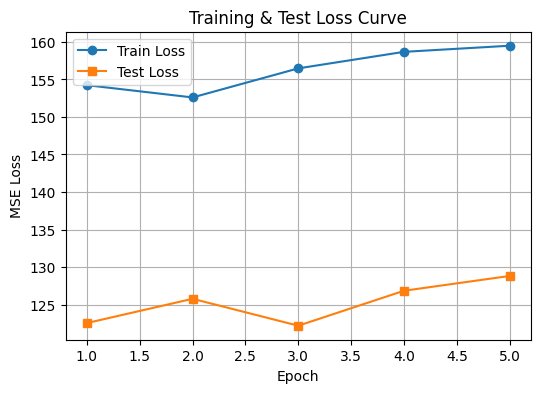

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [232]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for branch_name in train_loaders.keys():
    print(f"\nProcessing EO branch: {branch_name}")

    train_loader = train_loaders[branch_name]
    test_loader = test_loaders[branch_name]  # your separate test loader for generalization

    # Infer number of channels from dataset
    in_channels = train_loader.dataset[0][0].shape[0]

    # Initialize custom ViT
    model = ViTCustom(in_channels=in_channels)

    # Train model and track both train & test loss
    model = train_vit_with_test_loss(model, train_loader, test_loader, epochs=5, device=device)

    # Extract embeddings from the train set (or you could use test set embeddings if desired)
    embeddings, targets = extract_embeddings(model, train_loader, device=device)

    # Visualize in 3D using Plotly
    visualize_umap_3d(embeddings, targets, title=f"UMAP 3D - {branch_name}")



https://chatgpt.com/c/69177d0d-6574-8330-9022-d71e12822e03